# Analyze imgep dataset
This documents illustrates how imgep can be used to explore a simulator of a dual core architecture to tackle the discovery of inter-core  interference patterns.
## Definitions
We will be tackling the following notions when discussing about inteference.
* Mechanism: Behavior unit that is described as with a performance counter.
* Behavior: a dynamic during the execution on the platform. It can be made from multiple mechanisms.
* Interference source: An interference source is a component on the processor that has simultaneous use
by several cores or other initiators that may entail interferences. Examples of interference sources are shared caches and interconnect.

* **One aim at identifying all sources of interference for a given platform**

## Simulator
The dualcore simulator is made from a simple hierarchy with private L1 caches and a shared L2 cache, where interference can occur. It also contains a main DDR memory and its controller. These last two elements are shared resources and are therefore sources of interference. While exploring our system, one will execute programs in parallel to induce interference events.

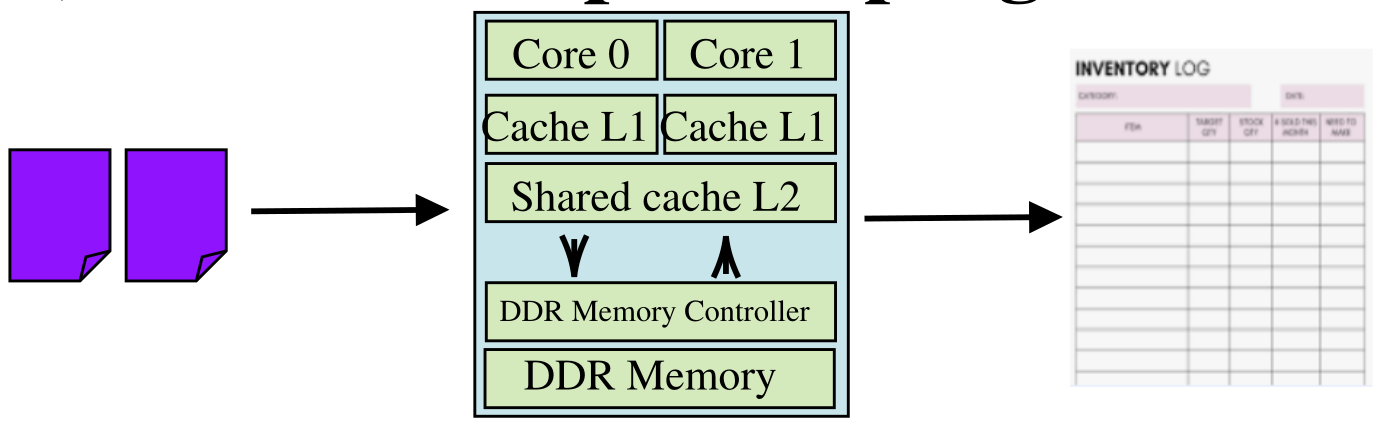

In [1]:
from IPython.display import Image
Image(filename='illustrations/experience.png',width=500) 

## Parameter space 
* The simulator takes as input pairs of short simplified assembly codes of the shape: {cycle:(type,address)}
* There are only two types **read** and **write**, as memory instructions hire the memory components that are the main sources of interference.
Ex: One can execute (p0,p1) with p0 = p1 = {23:(read,5),32:(read,8),64:(write,5)}.
*  **Addresses that are used are numbered from 0 to 20.**
*  Core 0 exploits address range 0 to 9
*  Core 1 exploits address range 10 to 19
* **Each program contains between 1 and 10 instruction.**
## Observation space explored by IMGEP
### Characterization 1
Phenomena quantified by performance counters allow the description of conflicts occurring in shared resources and thus are directly related to interference. However, information is agregated and very limited. We decide to take advantage of the fact that one can access to many information during an execution.

Because interference arises following micro-architectural conflicts, one can target are events related to the main types of interference.
**Wehn a program is executed, its collected events can be described using the following tables. 
#### A priori knowledge
**As we are only targeting the discovery of behaviors, one supposes that the range of technically reachable values for hardware variables are known. 
Thus, the range of possible values for `addresses`, `rows`, `banks`,`set_idx`, and `req_type` are known. However, the ranges of values for `scheduled_delay` and `nb_competing_requests` are unknown.**

| **Feature**                    | **Category** | **Description**                                                             |
|------------------------------|--------------|-----------------------------------------------------------------------------|
| Cache interference | L2 Cache     | Cross-core eviction tracking|
| DDR bank conflicts        | DDR          | When requests are delayed due to bank conflicts |
| DDR scheduler interference    | DDR Controller        |  Tracks when requests are delayed due to higher priority requests  |
| BUS contention  | BUS          | When requests are delayed due to bus bandwidth limitations |

More precisely, features are made with the following variables.
| **Feature**        | **variables**                                                                                                                       |
|--------------------|--------------------------------------------------------------------------------------------------------------------------------------|
| **DDR**            | 'row','bank','addr','req_type','scheduled_delay','core_id'                                                                           |
| **DDR scheduler**  | 'bank','addr','req_type','scheduled_delay','core_id', 'core_attacker','type_attacker','addr_attacker','bank_attacker','row_attacker' |
| **Cache interference**       | 'set_idx','evicted_core_id','evicted_instr_id','evicted_addr','causing_core_id','causing_addr'                                       |
| **Bus** | 'nb_competing_requests' 



We generate goals as dictionaries with their keys in [`Cache`,`DDR`,`DDR scheduler`,`Bus`].
#### Achievement strategy
A goal is made from at most one event per component.  Because all `events` do not correspond to vectors of the same dimension, targeting a goal can be done in the following way:

* For each feature *f* of a goal *g*:
    * Select the closest `k` previously collected events
    * Mix the collected corresponding assembly codes
* Mix the obtained mixtures of assembly codes we obtained for each feature to obtain a candidate parameter

### Characterization 2
One half of the time during imgep, one can use the second following characterization. 
* For each experiment, one determinsa dictionnary that tells what type of interference occured: {`DDR`:yes/no, `DDR scheduler`:yes/no,`Cache`:yes/no,`Bus`:yes/no} and stores it in the history.
* Then, we can sample a goal with the same format by sampling a combination of the desired elements from the superset of {`DDR`, `DDR scheduler`,`Cache`,`Bus`}. For example, we sample the goal {`DDR`:yes, `DDR scheduler`:no,`Cache`:no,`Bus`:yes}.
  
As there are 4 types of features/major components, the cardinal of the superset is 16. This characterization will help discovering more complex behaviors, as it correponds to associations between the componenents that are somtimes rare.

#### Achievement strategy
* For a goal *g*:
    * Select the closest `k` previously collected dictionnaries {`DDR`:yes/no, `DDR scheduler`:yes/no,`Cache`:yes/no,`Bus`:yes/no}.
    * Mix the collected corresponding assembly codes
* Tthe obtained code is a candidate parameter for the goal *g*.

### The following scheme shows how imgep work with the characterization 1

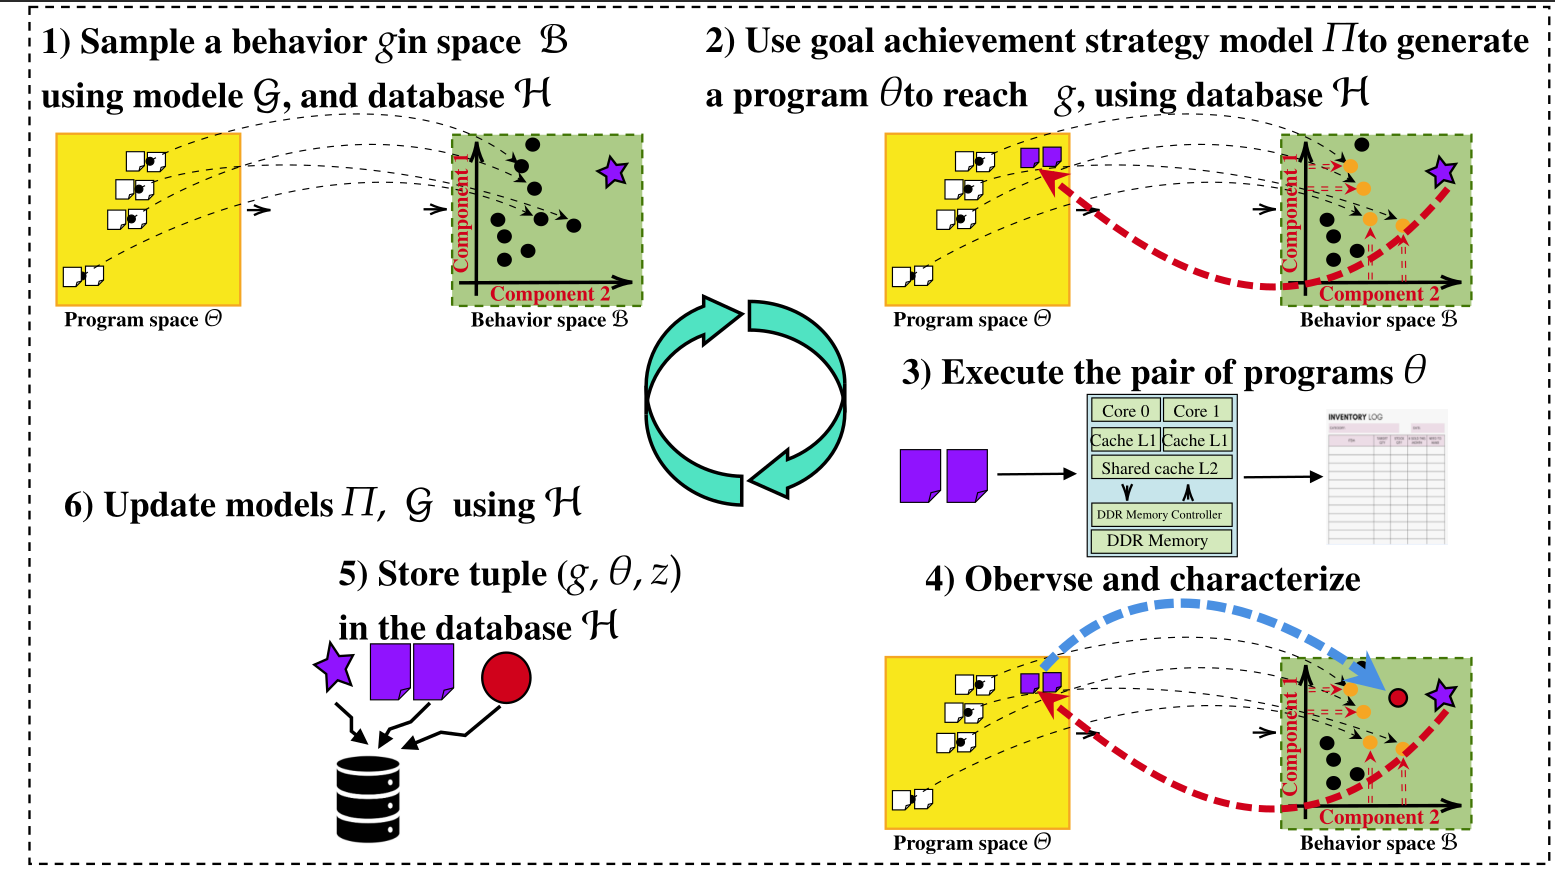

In [2]:
from IPython.display import Image
Image(filename='illustrations/illustration_method.png',width=600) 

## Load exploration results

In [3]:
import pickle
import numpy  as np
from exploration.load_file import load
from diversity.diversty import Diversity
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN

#Load data
folder = "results"
N = 20000
k=1
name_imgep = f'{folder}/imgep_detailled_if_N_{N}_k_{k}'
name_random = f'{folder}/random_detailled_if_N_{N}'
name_baseline = f'{folder}/baseline_detailled_if_N_{N}'
content_imgep,name_imgep = load(name_imgep)
content_random,name_random = load(name_random)
content_baseline,name_baseline = load(name_baseline)

results/imgep_detailled_if_N_20000_k_1_10.pkl
results/random_detailled_if_N_20000_17.pkl
results/baseline_detailled_if_N_20000_6.pkl


## Let's count the number of events for both a imgep and a random exploration

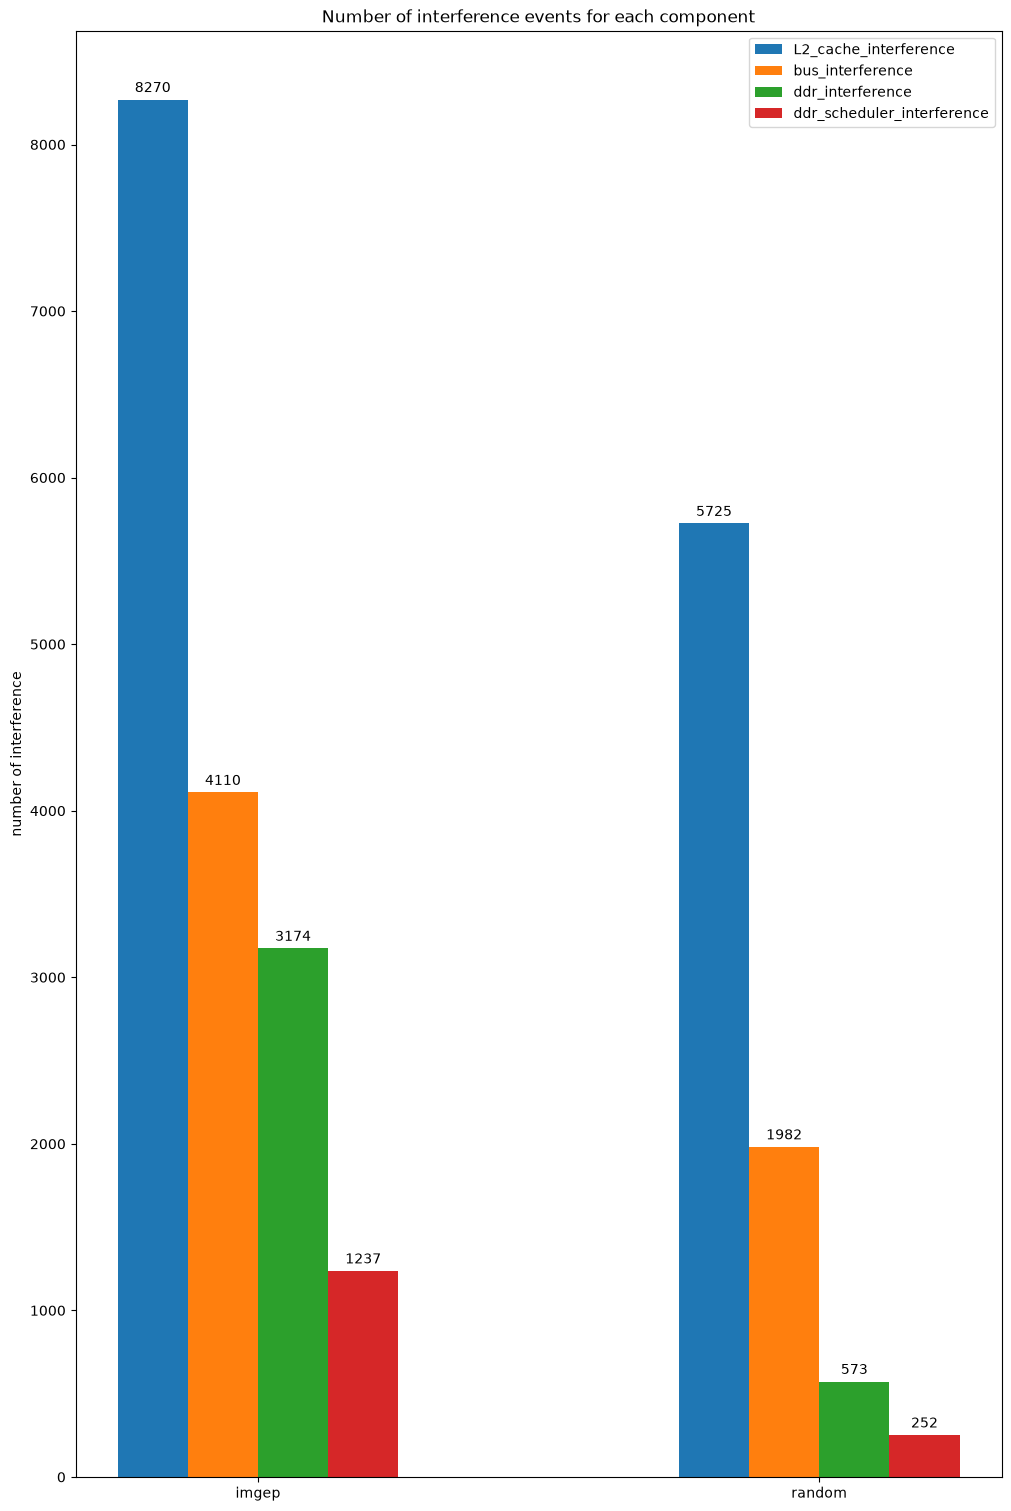

In [4]:
nb_events = {}
for j,content in enumerate([content_random,content_imgep]):
    for type_if in content_imgep['memory_observation']:
        keys = list(content['memory_observation'][type_if].keys())
        nb_events[type_if] = (len(content_imgep['memory_observation'][type_if].columns),len(content_random['memory_observation'][type_if].columns))

fig, ax = plt.subplots(layout='constrained',figsize=(10,15))

res = ax.grouped_bar(nb_events, tick_labels=['imgep','random'], group_spacing=4)
for container in res.bar_containers:
    ax.bar_label(container, padding=3)

# Add some text for labels, title, etc.
ax.set_ylabel('number of interference')
ax.set_title('Number of interference events for each component')
ax.legend(loc='upper right', ncols=1)
#ax.set_ylim(0, 250)
plt.savefig('nb_events.pdf')
plt.show()


## Number of distinct interferences for component
For both results of imgep and our random exploration, one can distinguish the interference events according to the major component involved (interconnect, ddr, ddr controller,shared L2 cache), and can also tell for each of them how many distinct interference there are.

**We list below the major components and the variables that characterize an interference on them. If the variables of two interference events are equalled, the interference is the same**

In [5]:
import numpy as np
import pandas as pd
from utils.history import History

history = History()
history._j = N
history.memory_observation = content_imgep['memory_observation']
for if_type in history.memory_observation:
    print(if_type,history.memory_observation[if_type].index)

L2_cache_interference Index(['set_idx', 'tag', 'evicted_core_id', 'evicted_instr_id', 'evicted_addr',
       'causing_core_id', 'causing_addr'],
      dtype='str')
bus_interference Index(['competing_requests'], dtype='str')
ddr_interference Index(['row', 'bank', 'addr', 'req_type', 'scheduled_delay', 'core_id'], dtype='str')
ddr_scheduler_interference Index(['bank', 'addr', 'req_type', 'scheduled_delay', 'core_id',
       'core_attacker', 'type_attacker', 'addr_attacker', 'bank_attacker',
       'row_attacker'],
      dtype='str')


In [6]:
merge_distinct_counts_evolution = {'random':{},'imgep':{},'baseline':{}}
history1 = History()
history1._j = N
history2 = History()
history2._j = N
history3 = History()
history3._j = N
history1.memory_observation = content_imgep['memory_observation']
history2.memory_observation = content_random['memory_observation']
history3.memory_observation = content_baseline['memory_observation']
for j,history in enumerate([history1,history2,history3]):
    for type_if in content_imgep['memory_observation'].keys():
        merge_distinct_counts_evolution[['imgep','random','baseline'][j]][type_if] = [np.unique(history.as_tab(type_if)[:lim],axis=1).shape[1] for lim in range(1,N,1000)]

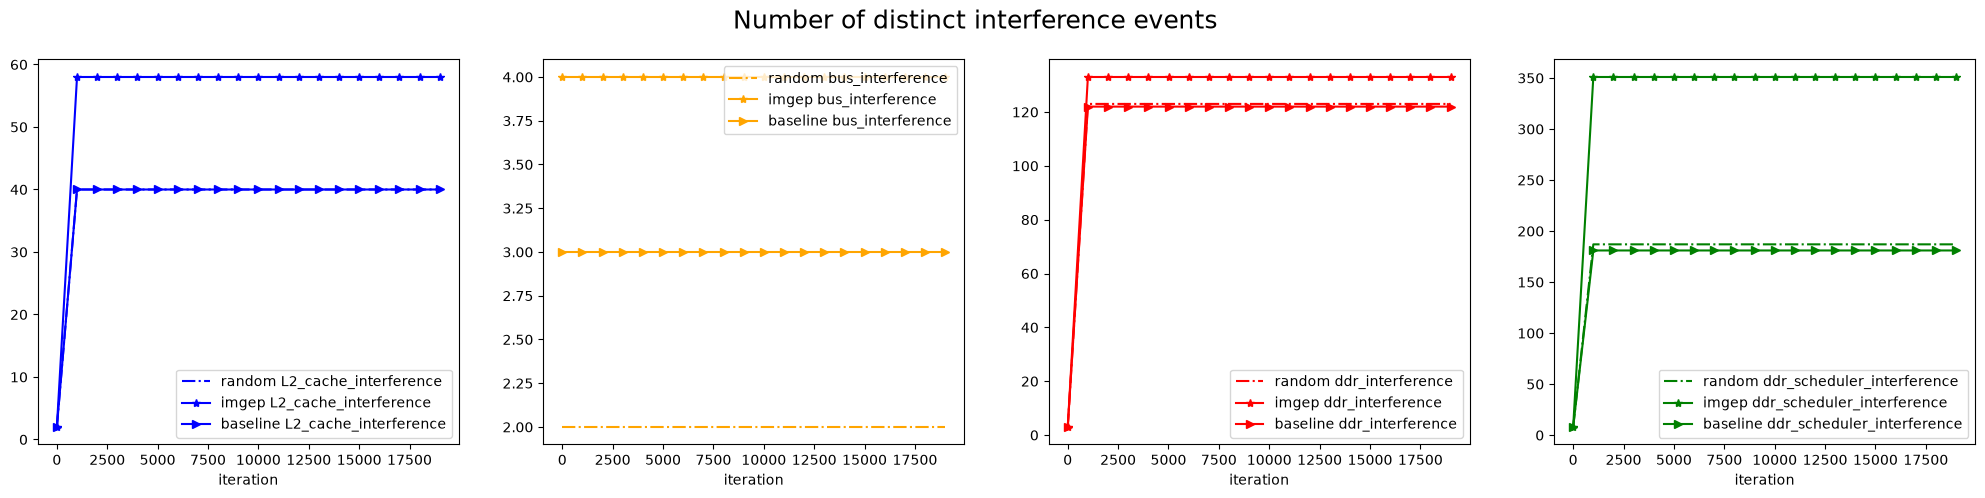

In [7]:
colors = ['blue','orange','red','green','purple']
fig,axs = plt.subplots(1,4,figsize=(25,5))
for j,if_type in enumerate(merge_distinct_counts_evolution['random'].keys()):
    axs[j].plot(range(1,N,1000),merge_distinct_counts_evolution['random'][if_type],'-.',label='random '+if_type,color=colors[j])
    axs[j].plot(range(1,N,1000),merge_distinct_counts_evolution['imgep'][if_type],'-*',label='imgep '+if_type,color=colors[j])
    axs[j].plot(range(1,N,1000),merge_distinct_counts_evolution['baseline'][if_type],'->',label='baseline '+if_type,color=colors[j])
    axs[j].legend()
    axs[j].set_xlabel('iteration')
plt.suptitle('Number of distinct interference events',fontsize=18)
plt.show()

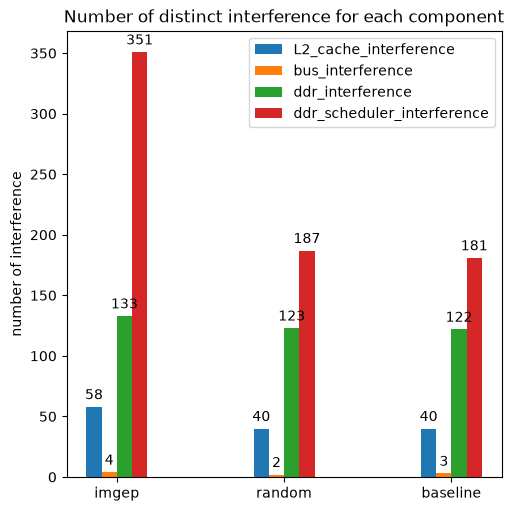

In [8]:
merge_distinct_counts = {}
for type_if in content_imgep['memory_observation'].keys():
    merge_distinct_counts[type_if] = (merge_distinct_counts_evolution['imgep'][type_if][-1],
                                          merge_distinct_counts_evolution['random'][type_if][-1],
                                         merge_distinct_counts_evolution['baseline'][type_if][-1])
    

fig, ax = plt.subplots(layout='constrained',figsize=(5,5))

res = ax.grouped_bar(merge_distinct_counts, tick_labels=['imgep','random','baseline'], group_spacing=7)
for container in res.bar_containers:
    ax.bar_label(container, padding=3)

# Add some text for labels, title, etc.
ax.set_ylabel('number of interference')
ax.set_title('Number of distinct interference for each component')
ax.legend(loc='upper right', ncols=1)
#ax.set_ylim(0, 250)
plt.savefig('nb_distinct_events_components.pdf')
plt.show()

# Different types of behaviors

As we generate programs that are between 1 and 10 instructions long, **we define in this case a behavior as a combination of interference events on distinct components** (interconnect,ddr,ddr controller,shared L2 cache). As there are 4 components, the powerset of {interconnect,ddr,ddr controller,shared L2 cache} contains 15 non-empty subsets.

We would like IMGEP to find as many combinations as possible.

In [9]:
list_types = list(content_imgep['memory_observation'].keys())

In [10]:
def select_idx_evolution(sub_list_types,list_types,content):
    '''
    selects programs that exhibit all of interference types from list_types;
    Returns the number of programs that exhibit only and all of interference types from list_types
    '''
    step = 10
    count = 0
    selection_tab = []
    selection = np.zeros((N,))
    nb_distinct_events = np.zeros((N,))
    selection_list_idx = []
    for i in range(N):
        s = 0
        sn = 0
        tabs = []
        for if_type in list_types:
            if i in content['memory_observation'][if_type].columns:
                if if_type in sub_list_types:
                    s+=1
                else:
                    sn+=1
                    break
        if s==len(sub_list_types) and sn==0:
            if i==0:
                selection[i] = 1
            else:
                selection[i] = selection[i-1]+1
            selection_list_idx.append(i)
            if len(sub_list_types)>0:
                vec = np.concatenate([content['memory_observation'][if_type][i] for if_type in sub_list_types],axis=0)
                if len(selection_tab)==0:
                    selection_tab.append(vec)
                if not(len(vec) in (vec==np.array(selection_tab)).sum(axis=1)):
                    selection_tab.append(vec)
        else:
            if i>0:
                selection[i] = selection[i-1]
            else:
                selection[i] = 0
        nb_distinct_events[i] = len(selection_tab)
    return range(0,N,step),selection,nb_distinct_events,selection_list_idx,selection_tab

In [11]:
from itertools import combinations

def get_all_subsets(input_list):
    subsets = []
    for r in range(len(input_list) + 1):
        # combinations() returns tuples, so we convert them to lists
        for combo in combinations(input_list, r):
            subsets.append(list(combo))
    return subsets
power_set = get_all_subsets(list_types)

In [12]:
Nb_events_imgep = {j:select_idx_evolution(subset,list_types,content_imgep)[2] for j,subset in enumerate(power_set)}
Nb_events_random = {j:select_idx_evolution(subset,list_types,content_random)[2] for j,subset in enumerate(power_set)}
Nb_events_baseline = {j:select_idx_evolution(subset,list_types,content_baseline)[2] for j,subset in enumerate(power_set)}

In [13]:
Nb_events_imgep = pd.DataFrame(Nb_events_imgep)
Nb_events_random = pd.DataFrame(Nb_events_random)
Nb_events_baseline = pd.DataFrame(Nb_events_baseline)

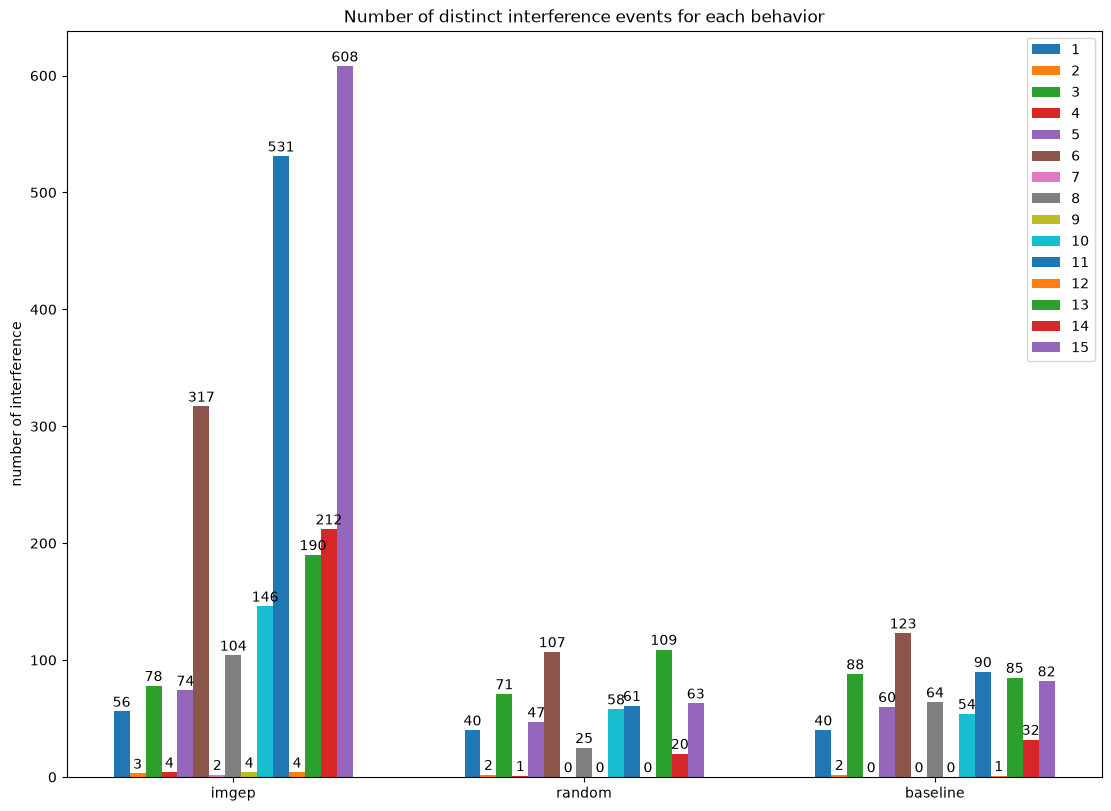

In [14]:
behavior_counts = {}
for j,subset in enumerate(power_set):
    behavior_counts[j] = (Nb_events_imgep[j][19999],Nb_events_random[j][19999],Nb_events_baseline[j][19999])
del behavior_counts[0]
fig, ax = plt.subplots(layout='constrained',figsize=(11,8))

res = ax.grouped_bar(behavior_counts, tick_labels=['imgep','random','baseline'], group_spacing=7)
for container in res.bar_containers:
    ax.bar_label(container, padding=1)

# Add some text for labels, title, etc.
ax.set_ylabel('number of interference')
ax.set_title('Number of distinct interference events for each behavior')
ax.legend(loc='upper right', ncols=1)
plt.savefig('stats_behaviors.pdf',bbox_inches='tight')
plt.show()

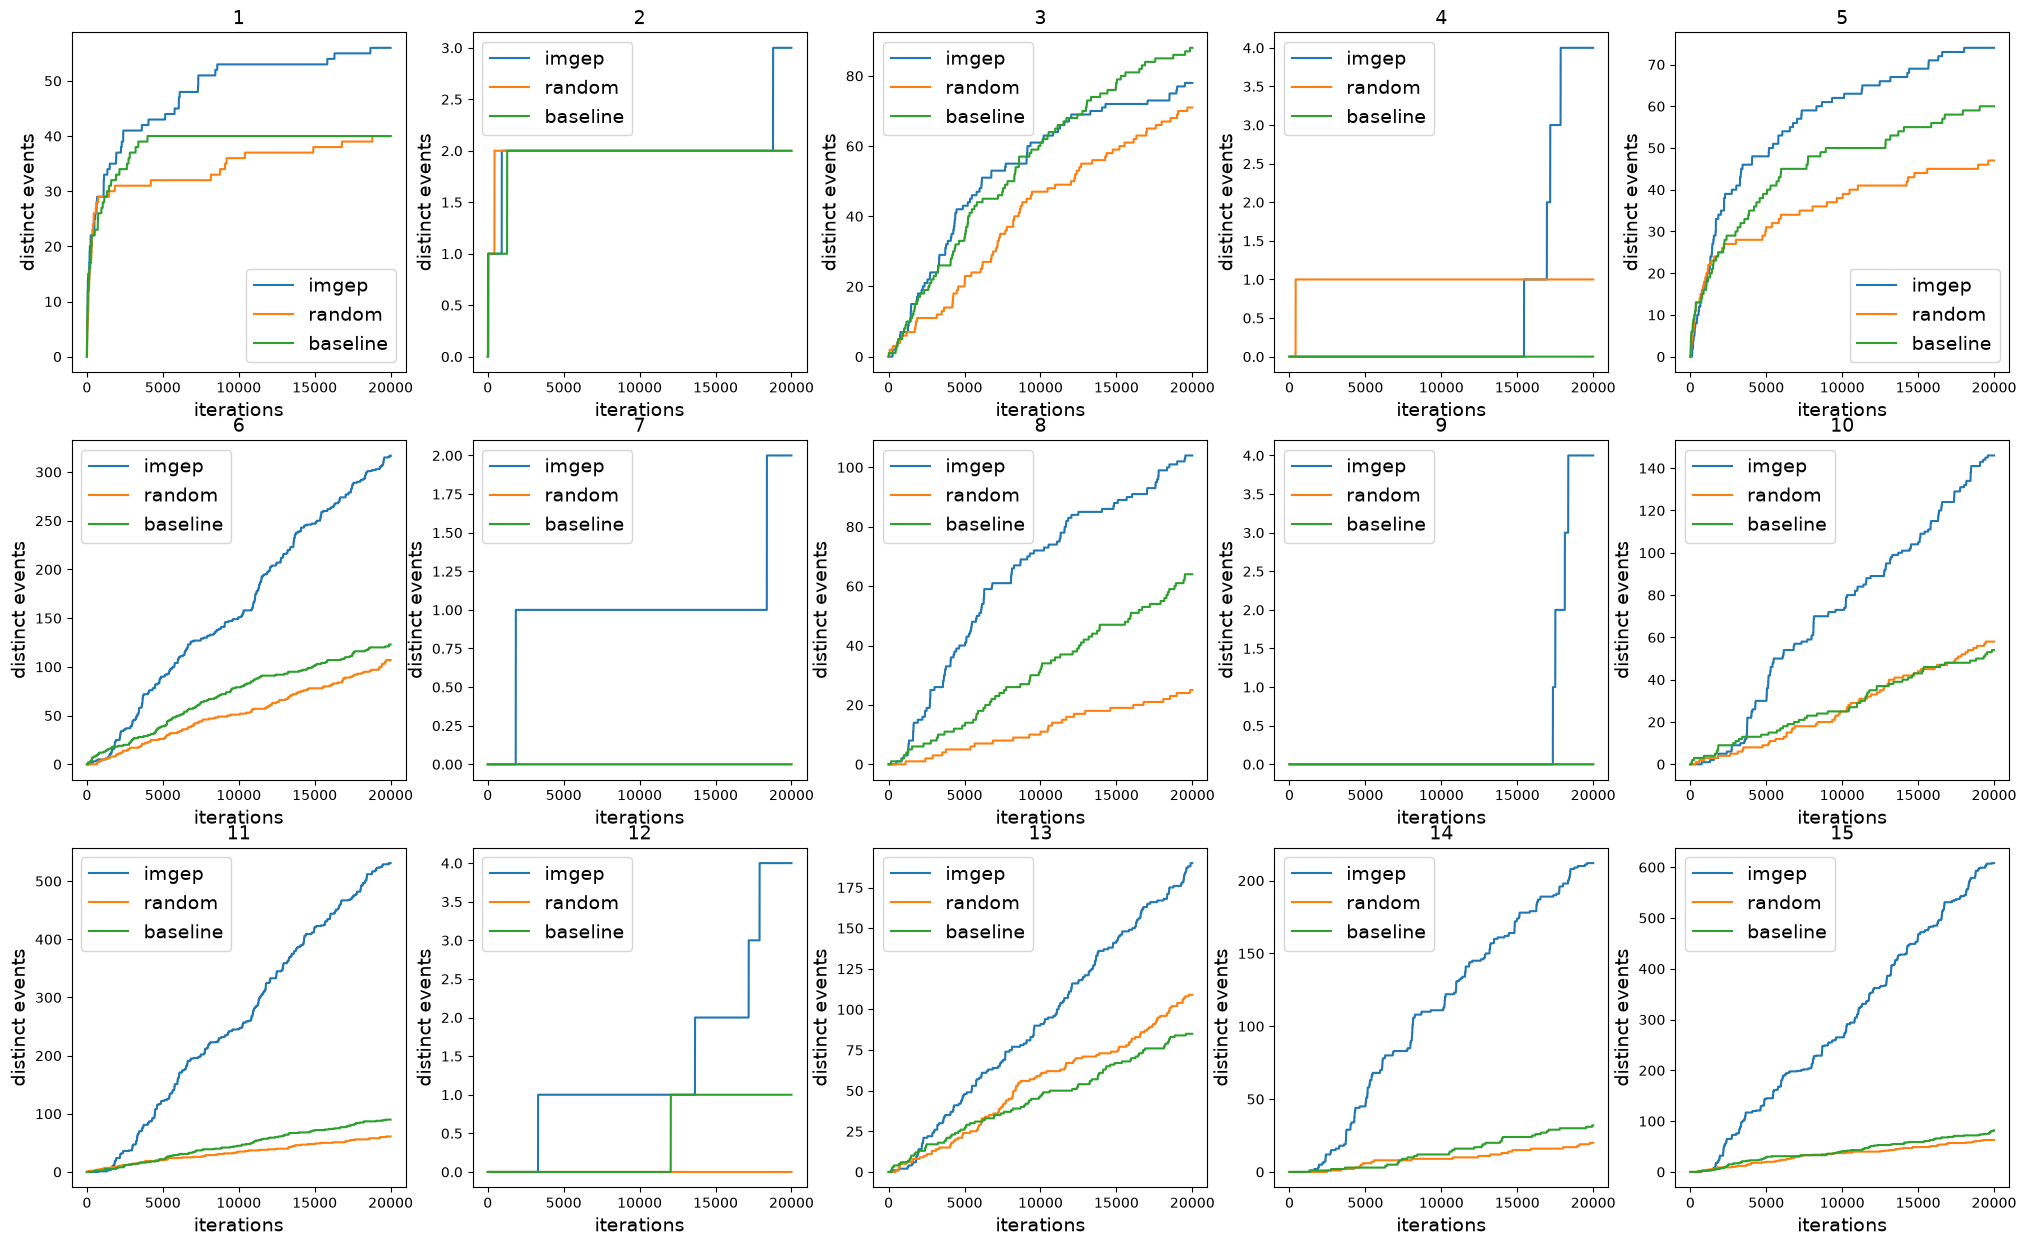

In [15]:
fig,axs = plt.subplots(3,5,figsize=(25,15))
for j in range(0,len(power_set[1:])):
    axs[j//5,j%5].plot(range(0,N),Nb_events_imgep[j+1],label='imgep')
    axs[j//5,j%5].plot(range(0,N),Nb_events_random[j+1],label='random')
    axs[j//5,j%5].plot(range(0,N),Nb_events_baseline[j+1],label='baseline')
    axs[j//5,j%5].legend(fontsize=14)
    axs[j//5,j%5].set_title(j+1,fontsize=14)
    axs[j//5,j%5].set_xlabel('iterations',fontsize=14)
    axs[j//5,j%5].set_ylabel('distinct events',fontsize=14)
#plt.suptitle('Number of distinct events',fontsize=18)
plt.savefig('stats_behaviors_evolution.pdf',bbox_inches='tight')
plt.show()


### Bellow the print the combinations of components that are illustrated above

In [21]:
for i,subset in enumerate(power_set):
    if i:
        print(i,[vec[:-13] for vec in power_set[i]])

1 ['L2_cache']
2 ['ddr']
3 ['ddr_scheduler']
4 ['bus']
5 ['L2_cache', 'ddr']
6 ['L2_cache', 'ddr_scheduler']
7 ['L2_cache', 'bus']
8 ['ddr', 'ddr_scheduler']
9 ['ddr', 'bus']
10 ['ddr_scheduler', 'bus']
11 ['L2_cache', 'ddr', 'ddr_scheduler']
12 ['L2_cache', 'ddr', 'bus']
13 ['L2_cache', 'ddr_scheduler', 'bus']
14 ['ddr', 'ddr_scheduler', 'bus']
15 ['L2_cache', 'ddr', 'ddr_scheduler', 'bus']


## Faire statistique sur nombre de cmpts decouverts

## Faire boucle sur 100 imgep and regarder nombre de fois les comportements sont non nuls

In [38]:
df_imgep_dict = {15:[],13:[]}
df_random_dict = {15:[],13:[]}
for key in [13,15]:
    print(key)
    index = []
    for if_type in power_set[key]:
        index += [txt + '_'+if_type[:-13] for txt in list(content_imgep['memory_observation'][if_type].index)]
    print(index)
    df_imgep_dict[key] = pd.DataFrame(np.array(select_idx_evolution(power_set[key],list_types,content_imgep)[4]),columns=index)
    array = np.array(select_idx_evolution(power_set[key],list_types,content_random)[4])
    if key==7:
        print(array)
    df_random_dict[key] = pd.DataFrame(array,columns=index)

13
['competing_requests_bus', 'row_ddr', 'bank_ddr', 'addr_ddr', 'req_type_ddr', 'scheduled_delay_ddr', 'core_id_ddr', 'bank_ddr_scheduler', 'addr_ddr_scheduler', 'req_type_ddr_scheduler', 'scheduled_delay_ddr_scheduler', 'core_id_ddr_scheduler', 'core_attacker_ddr_scheduler', 'type_attacker_ddr_scheduler', 'addr_attacker_ddr_scheduler', 'bank_attacker_ddr_scheduler', 'row_attacker_ddr_scheduler']
15
['competing_requests_bus', 'set_idx_L2_cache', 'tag_L2_cache', 'evicted_core_id_L2_cache', 'evicted_instr_id_L2_cache', 'evicted_addr_L2_cache', 'causing_core_id_L2_cache', 'causing_addr_L2_cache', 'row_ddr', 'bank_ddr', 'addr_ddr', 'req_type_ddr', 'scheduled_delay_ddr', 'core_id_ddr', 'bank_ddr_scheduler', 'addr_ddr_scheduler', 'req_type_ddr_scheduler', 'scheduled_delay_ddr_scheduler', 'core_id_ddr_scheduler', 'core_attacker_ddr_scheduler', 'type_attacker_ddr_scheduler', 'addr_attacker_ddr_scheduler', 'bank_attacker_ddr_scheduler', 'row_attacker_ddr_scheduler']


In [39]:
for comp in df_imgep_dict[13]:
    print(comp,np.unique(df_imgep_dict[13][comp].values))

competing_requests_bus [2 3 4]
row_ddr [0 1 2]
bank_ddr [0 1 2 3 4 5 6 7]
addr_ddr [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
req_type_ddr [-1  1]
scheduled_delay_ddr [4 5 6 7 8 9]
core_id_ddr [0 1]
bank_ddr_scheduler [0 1 2 3 4 5 6 7]
addr_ddr_scheduler [ 0  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
req_type_ddr_scheduler [-1  1]
scheduled_delay_ddr_scheduler [ 0  1  2  3  4  5  6  7  8  9 10 49 50]
core_id_ddr_scheduler [0 1]
core_attacker_ddr_scheduler [0 1]
type_attacker_ddr_scheduler [1]
addr_attacker_ddr_scheduler [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
bank_attacker_ddr_scheduler [0 1 2 3 4 5 6 7]
row_attacker_ddr_scheduler [0 1 2]


In [41]:
corr = df_imgep_dict[15].corr()
corr.style.background_gradient(cmap='coolwarm')

,competing_requests_bus,set_idx_L2_cache,tag_L2_cache,evicted_core_id_L2_cache,evicted_instr_id_L2_cache,evicted_addr_L2_cache,causing_core_id_L2_cache,causing_addr_L2_cache,row_ddr,bank_ddr,addr_ddr,req_type_ddr,scheduled_delay_ddr,core_id_ddr,bank_ddr_scheduler,addr_ddr_scheduler,req_type_ddr_scheduler,scheduled_delay_ddr_scheduler,core_id_ddr_scheduler,core_attacker_ddr_scheduler,type_attacker_ddr_scheduler,addr_attacker_ddr_scheduler,bank_attacker_ddr_scheduler,row_attacker_ddr_scheduler
competing_requests_bus,1.000000,0.014783,-0.069541,-0.050918,-0.012454,-0.064571,0.050918,0.064571,0.024272,0.005317,0.026031,0.026151,0.019445,0.014878,0.008239,-0.015697,0.029641,0.048840,-0.037059,0.040931,0.013940,0.050844,0.008702,0.047789
set_idx_L2_cache,0.014783,1.000000,-0.329426,0.232480,-0.002603,0.185209,-0.232480,-0.185209,-0.024594,0.234323,0.053783,0.050880,-0.063978,0.045332,0.241814,-0.019958,-0.056275,-0.062135,-0.010901,0.013483,0.027123,0.023331,0.235968,-0.055057
tag_L2_cache,-0.069541,-0.329426,1.000000,0.706440,0.019282,0.866834,-0.706440,-0.866834,-0.064871,-0.100283,-0.098353,-0.037951,-0.040973,-0.092155,-0.123970,-0.350561,-0.014622,-0.038329,-0.325514,0.322611,0.026347,0.408353,-0.123243,0.447914
evicted_core_id_L2_cache,-0.050918,0.232480,0.706440,1.000000,0.007249,0.858027,-1.000000,-0.858027,-0.111906,0.099401,-0.078575,-0.006783,-0.089106,-0.064714,0.071992,-0.371455,-0.030524,-0.079398,-0.342227,0.343600,0.037295,0.392453,0.071210,0.367532
evicted_instr_id_L2_cache,-0.012454,-0.002603,0.019282,0.007249,1.000000,0.018694,-0.007249,-0.018694,-0.016657,0.080498,0.010275,-0.018357,0.018302,0.006379,0.055955,-0.030971,-0.019293,-0.046543,-0.009984,0.003533,0.026442,0.011130,0.053738,-0.006741
evicted_addr_L2_cache,-0.064571,0.185209,0.866834,0.858027,0.018694,1.000000,-0.858027,-1.000000,-0.080505,0.019365,-0.073964,-0.012630,-0.076429,-0.071975,-0.001332,-0.375401,-0.044936,-0.072705,-0.344550,0.342892,0.041744,0.437333,-0.003662,0.437113
causing_core_id_L2_cache,0.050918,-0.232480,-0.706440,-1.000000,-0.007249,-0.858027,1.000000,0.858027,0.111906,-0.099401,0.078575,0.006783,0.089106,0.064714,-0.071992,0.371455,0.030524,0.079398,0.342227,-0.343600,-0.037295,-0.392453,-0.071210,-0.367532
causing_addr_L2_cache,0.064571,-0.185209,-0.866834,-0.858027,-0.018694,-1.000000,0.858027,1.000000,0.080505,-0.019365,0.073964,0.012630,0.076429,0.071975,0.001332,0.375401,0.044936,0.072705,0.344550,-0.342892,-0.041744,-0.437333,0.003662,-0.437113
row_ddr,0.024272,-0.024594,-0.064871,-0.111906,-0.016657,-0.080505,0.111906,0.080505,1.000000,-0.164892,0.944044,0.027422,0.006421,0.822603,-0.207760,0.400224,0.062967,0.049587,0.329339,-0.326646,0.018741,-0.242049,-0.212709,-0.170662
bank_ddr,0.005317,0.234323,-0.100283,0.099401,0.080498,0.019365,-0.099401,-0.019365,-0.164892,1.000000,0.169639,0.092222,-0.015844,0.149911,0.839093,-0.080681,0.126617,-0.227905,-0.128529,0.148199,0.049161,0.131985,0.831748,-0.144483


In [744]:
corr = df_dict[13].corr()
corr.style.background_gradient(cmap='coolwarm')

,set_idx_L2_cache,tag_L2_cache,evicted_core_id_L2_cache,evicted_instr_id_L2_cache,evicted_addr_L2_cache,causing_core_id_L2_cache,causing_addr_L2_cache,row_ddr,bank_ddr,addr_ddr,req_type_ddr,scheduled_delay_ddr,core_id_ddr,bank_ddr_scheduler,addr_ddr_scheduler,req_type_ddr_scheduler,scheduled_delay_ddr_scheduler,core_id_ddr_scheduler,core_attacker_ddr_scheduler,type_attacker_ddr_scheduler,addr_attacker_ddr_scheduler,bank_attacker_ddr_scheduler,row_attacker_ddr_scheduler
set_idx_L2_cache,1.000000,-0.486525,0.027634,0.018106,0.290355,-0.027634,0.275082,-0.021192,0.300287,0.096636,0.010095,-0.021970,-0.018006,0.298586,0.080092,-0.011154,-0.022168,-0.033377,0.032908,0.052940,0.159519,0.298144,0.038357
tag_L2_cache,-0.486525,1.000000,-0.029438,0.047974,0.694763,0.029438,0.407504,0.324451,-0.323394,0.208523,0.020000,0.005460,0.024772,-0.337022,0.217245,0.031675,0.100020,0.021976,-0.022908,-0.044406,0.493745,-0.335843,0.552121
evicted_core_id_L2_cache,0.027634,-0.029438,1.000000,-0.075263,-0.009493,-1.000000,0.022890,0.050154,-0.052541,0.031226,0.001571,-0.039632,-0.354574,-0.041952,0.021267,-0.012297,-0.030218,-0.587267,0.585043,0.048248,-0.000428,-0.041330,0.013852
evicted_instr_id_L2_cache,0.018106,0.047974,-0.075263,1.000000,0.067451,0.075263,0.093058,-0.015472,-0.155076,-0.077281,0.009861,-0.027023,0.013071,-0.162345,-0.091997,-0.058145,0.187614,0.029133,-0.032893,0.009861,0.142596,-0.162793,0.182112
evicted_addr_L2_cache,0.290355,0.694763,-0.009493,0.067451,1.000000,0.009493,0.672794,0.337922,-0.107001,0.307947,0.030217,-0.012106,0.012309,-0.123329,0.303881,0.025510,0.091302,-0.003407,0.002001,-0.005055,0.672117,-0.122401,0.636309
causing_core_id_L2_cache,-0.027634,0.029438,-1.000000,0.075263,0.009493,1.000000,-0.022890,-0.050154,0.052541,-0.031226,-0.001571,0.039632,0.354574,0.041952,-0.021267,0.012297,0.030218,0.587267,-0.585043,-0.048248,0.000428,0.041330,-0.013852
causing_addr_L2_cache,0.275082,0.407504,0.022890,0.093058,0.672794,-0.022890,1.000000,0.354048,-0.160927,0.303361,0.030788,0.024886,-0.000529,-0.163068,0.305256,0.026446,0.017464,-0.042547,0.041115,0.066013,0.601016,-0.162101,0.587125
row_ddr,-0.021192,0.324451,0.050154,-0.015472,0.337922,-0.050154,0.354048,1.000000,-0.280984,0.925381,0.026876,0.026661,-0.051600,-0.271560,0.873459,0.031690,0.078337,-0.053749,0.050901,0.061207,0.420958,-0.269614,0.464971
bank_ddr,0.300287,-0.323394,-0.052541,-0.155076,-0.107001,0.052541,-0.160927,-0.280984,1.000000,0.103750,0.068420,-0.033853,0.012478,0.977164,0.092154,0.037023,-0.215921,0.030181,-0.024979,0.023377,-0.159833,0.974270,-0.476768
addr_ddr,0.096636,0.208523,0.031226,-0.077281,0.307947,-0.031226,0.303361,0.925381,0.103750,1.000000,0.054876,0.014260,-0.048548,0.104498,0.941610,0.047465,-0.004093,-0.043783,0.042886,0.072665,0.373136,0.105371,0.293576


In [16]:
for if_type in content_imgep['memory_observation']:
    print(if_type)
    print(list(content_imgep['memory_observation'][if_type].index))

ddr_interference
['row', 'bank', 'addr', 'req_type', 'scheduled_delay', 'core_id']
ddr_scheduler_interference
['bank', 'addr', 'req_type', 'scheduled_delay', 'core_id', 'core_attacker', 'type_attacker', 'addr_attacker', 'bank_attacker', 'row_attacker']
L2_cache_interference
['set_idx', 'tag', 'evicted_core_id', 'evicted_instr_id', 'evicted_addr', 'causing_core_id', 'causing_addr']
bus_interference
['competing_requests']


In [22]:
jjj = select_idx_evolution(power_set[15],list_types,content_imgep)[3][0]

In [23]:
jjj

258

In [26]:
for if_type in content_imgep['memory_observation']:
    print('\n'+if_type + '\n')
    print(content_imgep['memory_observation'][if_type][jjj])


ddr_interference

row                 1
bank                2
addr               10
req_type            1
scheduled_delay     7
core_id             1
Name: 258, dtype: int64

ddr_scheduler_interference

bank                2
addr               10
req_type            1
scheduled_delay    54
core_id             1
core_attacker       0
type_attacker       1
addr_attacker       2
bank_attacker       2
row_attacker        0
Name: 258, dtype: int64

L2_cache_interference

set_idx              3
tag                  0
evicted_core_id      1
evicted_instr_id     4
evicted_addr        12
causing_core_id      0
causing_addr        12
Name: 258, dtype: int64

bus_interference

competing_requests    2
Name: 258, dtype: int64


In [27]:
content_imgep['memory_parameter'][jjj]

{'core0': {5: ('read', 2),
  7: ('write', 3),
  16: ('read', 14),
  18: ('write', 6),
  20: ('read', 9),
  25: ('read', 14),
  35: ('read', 18),
  36: ('read', 4),
  45: ('read', 13)},
 'core1': {4: ('read', 18),
  11: ('read', 10),
  12: ('read', 3),
  22: ('read', 17),
  24: ('read', 14),
  31: ('write', 2),
  33: ('read', 11),
  47: ('read', 11),
  60: ('write', 11)}}

In [ ]:
{'ddr_interference':

{'row ':                1,
'bank':                2,
'addr':               10,
'req_type':            1,
'scheduled_delay':     7,
'core_id':             1,},

ddr_scheduler_interference

bank                2
addr               10
req_type            1
scheduled_delay    54
core_id             1
core_attacker       0
type_attacker       1
addr_attacker       2
bank_attacker       2
row_attacker        0
Name: 258, dtype: int64

L2_cache_interference

set_idx              3
tag                  0
evicted_core_id      1
evicted_instr_id     4
evicted_addr        12
causing_core_id      0
causing_addr        12
Name: 258, dtype: int64

bus_interference

competing_requests    2

In [38]:
a = {if_type:content_imgep['memory_observation'][if_type][jjj].to_dict() for if_type in content_imgep['memory_observation']}

In [39]:
print(a)

{'ddr_interference': {'row': 1, 'bank': 2, 'addr': 10, 'req_type': 1, 'scheduled_delay': 7, 'core_id': 1}, 'ddr_scheduler_interference': {'bank': 2, 'addr': 10, 'req_type': 1, 'scheduled_delay': 54, 'core_id': 1, 'core_attacker': 0, 'type_attacker': 1, 'addr_attacker': 2, 'bank_attacker': 2, 'row_attacker': 0}, 'L2_cache_interference': {'set_idx': 3, 'tag': 0, 'evicted_core_id': 1, 'evicted_instr_id': 4, 'evicted_addr': 12, 'causing_core_id': 0, 'causing_addr': 12}, 'bus_interference': {'competing_requests': 2}}


In [37]:
content_imgep['memory_observation'][if_type][jjj].to_dict()

{'competing_requests': 2}